# dx-navigator: the mined symptom dataset

459 NHS condition pages, scraped for their symptom sections, with every
wording collapsed into one canonical vocabulary by embedding cosine.

Nothing here is clinically reviewed. It is a scrape plus a language model,
and the weights are corpus statistics, not published figures.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Works whether the kernel starts in the repo root or in notebooks/.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'scripts' / 'dataset.py').exists())
sys.path.insert(0, str(ROOT / 'scripts'))

from dataset import frames

pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 90)

d = frames()
{k: v.shape for k, v in d.items()}

{'conditions': (512, 8),
 'symptoms': (1305, 4),
 'links': (2944, 6),
 'matrix': (451, 1305)}

## conditions

One row per condition. `symptoms` holds the list, rarest first, so the head
of each list is the symptom that most nearly names the condition.

In [2]:
conditions = d['conditions']
conditions[conditions.n_symptoms > 0][['name', 'system', 'n_symptoms', 'symptoms']].head(15)

,name,system,n_symptoms,symptoms
0,Abdominal aortic aneurysm,cardiovascular,2,"[pulsing feeling in tummy, tummy or back pain]"
1,Acanthosis nigricans,unclassified,3,"[darker and thicker skin patches, skin patches, itchy skin]"
2,Achalasia,unclassified,9,"[choking and coughing fits, regurgitation, difficulty swallowing food or drink, swallo..."
4,Acne,skin,2,"[chest acne, back acne]"
5,Acoustic neuroma (vestibular schwannoma),neoplasm,8,"[limb co-ordination problems, blurred or double vision, facial drooping and body weakn..."
6,Acromegaly,neurological,8,"[oily skin, deeper voice, erection problems, numbness and weakness in hands, swollen f..."
7,Actinic keratoses (solar keratoses),neoplasm,4,"[dry rough scaly skin, skin lesion colour, skin patches, itchy skin]"
8,Actinomycosis,infectious,4,"[lumps in cheek or neck, pus leaking from chest skin, abdominal symptoms, lower tummy ..."
9,Acute cholecystitis,digestive,10,"[tummy bulge, sharp upper right abdominal pain, shoulder pain spreading, tummy tendern..."
10,Acute kidney injury (AKI),genitourinary,6,"[peeing less than usual, breathlessness, altered mental state and fatigue, increased t..."


In [3]:
# Look one up.
conditions.set_index('slug').loc['lung-cancer', 'symptoms']

['persistent breathlessness',
 'finger clubbing',
 'chest pain when breathing',
 'recurrent chest infections',
 'swollen face or neck',
 'coughing up blood',
 'persistent cough',
 'hoarse voice',
 'chest pain',
 'difficulty swallowing',
 'loss of appetite',
 'fatigue']

## symptoms

The canonical vocabulary. `idf` is inverse document frequency: high means
few conditions list it, so hearing it narrows things a lot.

This is the closest thing here to a likelihood ratio, and it is not one. It
says how rare a word is in this corpus, not how much the symptom shifts the
odds of a disease in a real population.

In [4]:
symptoms = d['symptoms']
pd.concat([
    symptoms.nsmallest(10, 'idf').assign(kind='says least'),
    symptoms[symptoms.n_conditions > 1].nlargest(10, 'idf').assign(kind='says most'),
])[['canonical', 'n_conditions', 'idf', 'kind']]

,canonical,n_conditions,idf,kind
37,high temperature,78,2.744234,says least
54,fatigue,65,2.924027,says least
49,nausea and vomiting,59,3.019338,says least
64,shortness of breath,47,3.242481,says least
40,loss of appetite,40,3.400110,says least
7,chest pain,25,3.855586,says least
12,difficulty swallowing,25,3.855586,says least
46,flu-like symptoms,25,3.855586,says least
440,muscle and joint aches,25,3.855586,says least
38,fatigue and nausea,23,3.935628,says least


## How thin is the data?

The honest answer to whether any of this can work.

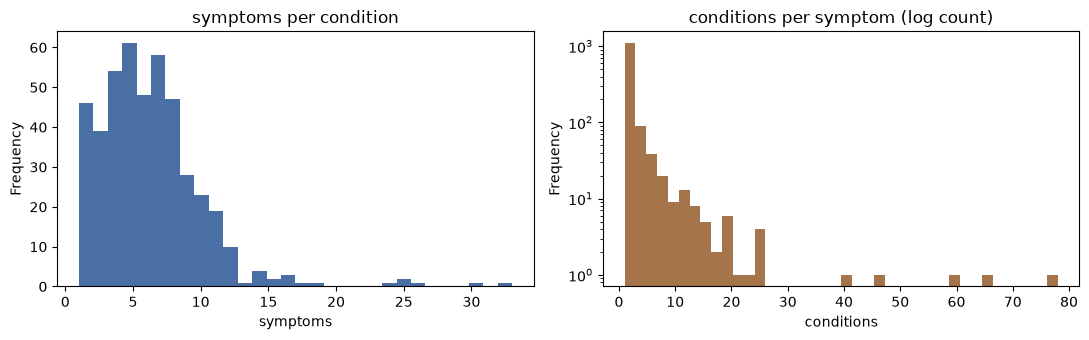

61 conditions have no symptoms at all
926 of 1305 symptoms appear in exactly one condition


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

conditions[conditions.n_symptoms > 0].n_symptoms.plot.hist(
    bins=30, ax=ax[0], color='#4a6fa5')
ax[0].set_title('symptoms per condition')
ax[0].set_xlabel('symptoms')

symptoms.n_conditions.plot.hist(bins=40, ax=ax[1], log=True, color='#a5744a')
ax[1].set_title('conditions per symptom (log count)')
ax[1].set_xlabel('conditions')

plt.tight_layout()
plt.show()

print(f"{(conditions.n_symptoms == 0).sum()} conditions have no symptoms at all")
print(f"{(symptoms.n_conditions == 1).sum()} of {len(symptoms)} symptoms appear in exactly one condition")

A symptom that appears in exactly one condition cannot be compared against
anything. It identifies that condition and is silent about every other. The
count above is the share of the vocabulary doing no discriminating work.

## The matrix

Conditions by symptoms, 0/1. This is what the scorer sees.

In [6]:
m = d['matrix']
print(f'{m.shape[0]} conditions x {m.shape[1]} symptoms, {m.to_numpy().mean():.2%} filled')
m.loc[['lung-cancer', 'asthma', 'pneumonia'],
      m.loc[['lung-cancer', 'asthma', 'pneumonia']].any()].T.head(20)

451 conditions x 1305 symptoms, 0.50% filled


condition,lung-cancer,asthma,pneumonia
canonical,,,
aching body,0,0,1
breathing problems,0,1,0
chest pain,1,1,1
chest pain when breathing,1,0,0
confusion,0,0,1
cough,0,0,1
coughing up blood,1,0,0
difficulty swallowing,1,0,0
fatigue,1,0,1


## Which conditions look alike?

Cosine between conditions in idf-weighted symptom space. Pairs near 1 are the
ones the tool will struggle to tell apart, because on this data they are the
same thing.

In [7]:
idf = symptoms.set_index('canonical').loc[m.columns, 'idf'].to_numpy()
w = m.to_numpy() * idf
unit = w / np.linalg.norm(w, axis=1, keepdims=True)
sim = unit @ unit.T
np.fill_diagonal(sim, 0)

i, j = np.triu_indices_from(sim, k=1)
pairs = (pd.DataFrame({'a': m.index[i], 'b': m.index[j], 'cosine': sim[i, j]})
         .nlargest(20, 'cosine')
         .reset_index(drop=True))
pairs

,a,b,cosine
0,hepatitis-a,hepatitis-b,0.861734
1,food-poisoning,typhus,0.838045
2,legionnaires-disease,middle-east-respiratory-syndrome-mers,0.768881
3,bladder-stones,hydronephrosis,0.764262
4,menieres-disease,otosclerosis,0.750769
5,coronary-heart-disease,heart-block,0.708446
6,glandular-fever,q-fever,0.697362
7,pulmonary-hypertension,wolff-parkinson-white-syndrome,0.690396
8,arrhythmia,heart-block,0.674909
9,bile-duct-cancer,hepatitis,0.670313


## Search it

Free text in, ranked conditions out. This calls Gemini, so it needs
`GEMINI_API_KEY` in the environment.

No prior is applied. A rare disease that matches the words ranks above a
common one that matches slightly fewer, which is not how a GP should think
and is the largest single thing missing from this dataset.

In [8]:
from triage_poc import Corpus, extract

c = Corpus()
c.set_alpha(0.25)

def search(text, n=10):
    matched = c.match(extract(text))
    ev = {sid: 1 for sid, _, _ in matched}
    scores = c.rank(ev)
    top = np.argsort(-scores)[:n]
    print('matched:', ', '.join(f'{p!r} -> {c.names[s]}' for s, p, _ in matched) or 'nothing')
    return pd.DataFrame({
        'condition': [c.display.get(c.conds[i], c.conds[i]) for i in top],
        'score': scores[top],
    })

search('dry cough for two months, coughing up blood, losing weight without trying')

matched: 'dry cough for two months' -> persistent cough, 'coughing up blood' -> coughing up blood, 'losing weight without trying' -> unexplained weight loss


,condition,score
0,Cancer,3.648001
1,Bronchiectasis,3.005266
2,Lung cancer,2.833578
3,Thrombophilia,1.928371
4,Pulmonary embolism,1.849616
5,Antiphospholipid syndrome (APS),1.579405
6,Silicosis,1.461591
7,Asbestosis,1.440822
8,Idiopathic pulmonary fibrosis,1.403916
9,Aspergillosis,1.366362


In [9]:
search('sudden crushing chest pain spreading to my left arm, sweating, feeling sick')

matched: 'sudden crushing chest pain spreading to left arm' -> chest pain, 'sweating' -> excessive sweating, 'feeling sick' -> feeling unwell


,condition,score
0,Slapped cheek syndrome,2.250622
1,Breast cancer in men,1.987936
2,Kidney cancer,1.763350
3,Phaeochromocytoma,1.747710
4,Cluster headaches,1.579807
5,Heat exhaustion and heatstroke,1.566619
6,"Blood pressure (high), see High blood pressure",1.069491
7,Pleurisy,1.016812
8,Heart block,1.008949
9,Asthma,0.984821


## What is wrong with this data

Worth reading before trusting any ranking above.

- **No prevalence.** Nothing knows a cold is commoner than lung cancer.
- **Umbrella pages rank as diagnoses.** `Cancer` is an NHS hub page, not
  something a GP diagnoses, but it scores like a condition.
- **A fifth of conditions are never retrieved.** In the held-out check the
  right answer failed to reach the top ten in about 20% of cases, and
  questioning cannot rescue what retrieval missed.
- **53 conditions have no symptoms.** Some genuinely have none (high
  cholesterol); others are pages the scraper could not read.
- **Severity is absent.** Nothing marks which symptoms mean 'send to hospital
  now'.

In [10]:
conditions[conditions.n_symptoms == 0][['slug', 'name', 'system']].head(20)

,slug,name,system
3,acid-and-chemical-burns,Acid and chemical burns,traumatic-or-injury
28,angelman-syndrome,Angelman syndrome,neurological
49,back-pain,Back pain,unclassified
52,bartholins-cyst,Bartholin's cyst,genitourinary
55,birthmarks,Birthmarks,skin
56,black-eye,Black eye,eye
60,blisters,Blisters,unclassified
61,boils,Boils,infectious
71,breast-cancer-in-women,Breast cancer in women,neoplasm
72,broken-ankle,Broken ankle,musculoskeletal
